# EDA de ERA5 sobre Cali

ERA5 es el reanálisis atmosférico del ECMWF, un modelo que reconstruye hora a hora el estado del aire combinando todas las observaciones disponibles con un pronóstico de fondo. No es un satélite ni una estación: es la mejor reconstrucción del clima pasado, y de ahí sacamos las variables que rodean a los contaminantes. Temperatura, humedad, viento, presión, radiación solar, lluvia y la altura de la capa de mezcla. Ninguna de esas mide contaminación; lo que miden es el ambiente que la diluye o la deja pegada al suelo.

Ese es justo el papel de ERA5 en el panel. Sentinel-5P ve la columna de NO2, SO2 y O3 desde el espacio, pero esa columna se vuelve concentración de superficie según cómo esté la atmósfera ese día. Con la capa de mezcla baja y el viento quieto, lo poco que hay se concentra; con la capa alta y viento, se reparte. Por eso ERA5 entra como covariable para bajar la columna satelital a la concentración que de verdad respira la ciudad.

Hay una cosa que conviene decir de una vez, porque marca todo el análisis. ERA5 mira Cali con muy pocas celdas, así que no sirve para dibujar mapas finos de la ciudad. Lo que sí hace bien es el tiempo: el ciclo del día, el de las estaciones y el de los años. Este recorrido va por ahí, por cómo se mueven las variables en el tiempo y por si los números tienen sentido físico para un valle tropical entre cordilleras.

## Preparación

Antes de mirar nada dejamos listo el entorno: las herramientas, el estilo de las figuras, dónde viven los datos, las constantes del dominio y las funciones que se repiten a lo largo del recorrido.

### *Importación de dependencias*

In [1]:
import io
import os
import zipfile
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

### *Estilo de las gráficas y semilla*

In [2]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

SEED = 137
rng = np.random.default_rng(SEED)

### *Ubicación de los datos*

In [3]:
def _buscar_datos():
    env = os.environ.get("ERA5_DIR")
    if env and Path(env).exists():
        return Path(env)
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / "data" / "era5"
        if cand.exists():
            return cand
    raise FileNotFoundError("No encuentro data/era5 desde el directorio actual")


ERA5 = _buscar_datos()
print("Datos ERA5:", ERA5)

Datos ERA5: C:\Users\mitgar14\Desktop\Ingenieria de Datos e IA - UAO\Semestre 7\Analítica\Semana #12 - #17\Proyecto\data\era5


### *Constantes del dominio*

In [4]:
# Cali y el recuadro amplio del Valle, los mismos que usan los EDA hermanos.
BBOX_CALI = (-76.60, 3.30, -76.40, 3.55)   # lonmin, latmin, lonmax, latmax

# Cali va cinco horas detrás de UTC. El sobrepaso de Sentinel-5P cae cerca de
# la 1:30 de la tarde local, o sea las 18:30 UTC.
UTC_OFFSET = -5
PASO_TROPOMI_LOCAL = 13.5

PERIODO = (date(2020, 1, 1), date(2024, 12, 31))

# Variables que llegan mes a mes y variables que llegan en un archivo por año.
VARS_MENSUAL = ["blh", "d2m", "sp", "ssr", "stl1", "t2m", "tp", "u10", "v10"]
VARS_ANUAL = ["u100", "v100"]
ACUMULADAS = {"ssr", "tp"}

# Las nueve estaciones de DAGMA (lon, lat), la referencia de suelo del proyecto.
ESTACIONES = {
    "Base Aérea": (-76.50653649, 3.45731978),
    "ERA Obrero": (-76.51908184, 3.44759410),
    "Cañaveralejo": (-76.54961789, 3.41545841),
    "Univalle": (-76.53372474, 3.37796681),
    "Pance": (-76.53125401, 3.30449556),
    "Transitoria": (-76.49495633, 3.41717874),
    "Compartir": (-76.46657547, 3.42825808),
    "La Flora": (-76.51805771, 3.48822548),
    "La Ermita": (-76.53097834, 3.45551754),
}

MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]

### *Funciones de apoyo*

In [5]:
def fmt(n, dec=0):
    """Número al estilo local: punto para miles, coma para decimales."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")


def leer_nc(path):
    """Abre un NetCDF de ERA5 y devuelve el Dataset.

    Las variables que vienen del bucket llegan empacadas en un ZIP con el
    NetCDF adentro; las de viento y capa de mezcla llegan como HDF5 directo.
    Se distingue por los dos primeros bytes y se lee todo desde memoria.
    """
    with open(path, "rb") as f:
        firma = f.read(2)
    if firma == b"PK":
        with zipfile.ZipFile(path) as z:
            crudo = z.read(z.namelist()[0])
    else:
        with open(path, "rb") as f:
            crudo = f.read()
    return xr.open_dataset(io.BytesIO(crudo), engine="h5netcdf")


def serie_espacial(v, anual=False):
    """Promedia la variable sobre su grilla y la concatena en el tiempo."""
    if anual:
        patron = "*_all_%s.nc" % v
    else:
        patron = "*_[0-9][0-9]_%s.nc" % v
    rutas = sorted(ERA5.glob(os.path.join("year=*", patron)))
    trozos = []
    n_celdas = None
    for ruta in rutas:
        ds = leer_nc(ruta)
        nombre = list(ds.data_vars)[0]
        ejes = [d for d in ds[nombre].dims if d != "valid_time"]
        n_celdas = int(np.prod([ds.sizes[d] for d in ejes]))
        media = ds[nombre].mean(dim=ejes)
        s = pd.Series(np.asarray(media.values, dtype="float64"),
                      index=pd.to_datetime(ds["valid_time"].values))
        trozos.append(s)
        ds.close()
    serie = pd.concat(trozos).sort_index()
    serie = serie[~serie.index.duplicated(keep="first")]
    return serie, len(rutas), n_celdas


def desacumular(serie):
    """Pasa una variable acumulada desde las 00 UTC a flujo de cada hora."""
    flujo = serie.diff()
    es_primera = serie.index.hour == 1
    flujo[es_primera] = serie[es_primera]
    return flujo


def magnus_rh(t_c, td_c):
    """Humedad relativa a partir de temperatura y punto de rocío en grados."""
    a, b = 17.625, 243.04
    return 100 * np.exp(a * td_c / (b + td_c)) / np.exp(a * t_c / (b + t_c))

Dos variables piden un cuidado especial antes de usarlas. La radiación solar y la precipitación no llegan como el valor de cada hora, sino sumadas desde la medianoche: el número de las 10 de la mañana es todo lo que se acumuló desde las 00 UTC hasta esa hora, y el contador se reinicia cada día. Para ver el aporte de una sola hora se resta la hora anterior:

$$F_h = A_h - A_{h-1}$$

donde $A_h$ es el valor acumulado a la hora $h$ y $F_h$ es el flujo de esa hora. La única excepción es la primera hora del día, las 01 UTC, donde el acumulado ya es el aporte de esa hora y se deja igual. Con la radiación en julios por metro cuadrado eso da la energía de cada hora, que dividida por los 3.600 segundos pasa a vatios por metro cuadrado; con la lluvia en metros, la diferencia por mil queda en milímetros.

La humedad relativa no viene en los archivos, se arma con la temperatura y el punto de rocío usando la fórmula de Magnus, que es la forma estándar de comparar cuánto vapor hay contra cuánto cabría a esa temperatura. Cuando los dos valores se acercan, el aire está casi saturado y la humedad sube hacia el 100 por ciento.

## 1. Qué traen los archivos

Lo primero es saber con qué se cuenta. Son once variables sobre Cali, hora por hora, de 2020 a 2024. Recorremos cada una, la promediamos sobre su grilla y la juntamos en una sola tabla de tiempo, anotando de paso cuántos archivos y cuántas celdas aporta cada una y si el calendario queda completo.

In [6]:
crudo = {}
inventario = []
for v in VARS_MENSUAL + VARS_ANUAL:
    serie, n_arch, n_celdas = serie_espacial(v, anual=(v in VARS_ANUAL))
    crudo[v] = serie
    inventario.append({"variable": v, "archivos": n_arch, "celdas": n_celdas,
                       "horas": len(serie), "acumulada": v in ACUMULADAS})
inv = pd.DataFrame(inventario).set_index("variable")

base = crudo["t2m"].index
esperadas = pd.date_range(base.min(), base.max(), freq="h")
faltan = len(esperadas) - len(base.unique())

print(f"Variables:        {len(inv)}")
print(f"Horas por serie:  {fmt(len(base))}  ({base.min().date()} a {base.max().date()})")
print(f"Horas faltantes:  {fmt(faltan)}")
print()
print(inv.to_string())

Variables:        11
Horas por serie:  43.848  (2020-01-01 a 2024-12-31)
Horas faltantes:  0

          archivos  celdas  horas  acumulada
variable                                    
blh             60       2  43848      False
d2m             60      12  43848      False
sp              60      12  43848      False
ssr             60      12  43848       True
stl1            60      12  43848      False
t2m             60      12  43848      False
tp              60      12  43848       True
u10             60      12  43848      False
v10             60      12  43848      False
u100             5       2  43848      False
v100             5       2  43848      False


Las once variables traen las 43.848 horas de los cinco años, sin un solo hueco en el calendario. Salen dos grupos por el tamaño de su grilla: nueve variables llegan mes a mes sobre doce celdas, que es la resolución fina de ERA5-Land cerca de 0,1 grados, y tres llegan con celdas más grandes, la altura de capa de mezcla y el viento a 100 metros, que vienen del producto estándar de ERA5 a 0,25 grados y solo alcanzan dos celdas. Esa diferencia de grilla no estorba para un análisis de tiempo, pero conviene tenerla presente: no todas las variables miran exactamente el mismo pedazo de Cali.

## 2. Dónde mira ERA5

Antes de meternos con los valores, conviene ver sobre el mapa qué tan grueso es el dato. Dibujamos las celdas de las dos grillas sobre el recuadro de Cali, junto con las nueve estaciones de DAGMA, para dimensionar cuánta ciudad cae en cada una.

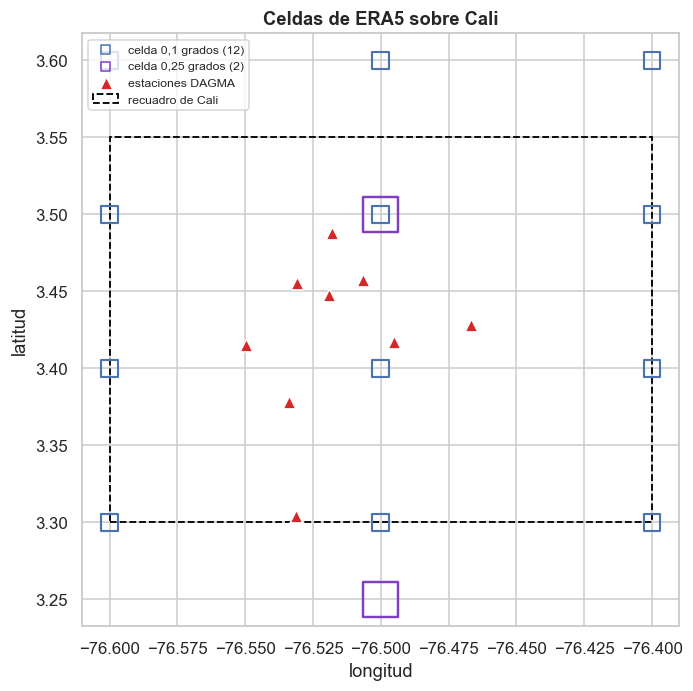

In [7]:
ds_fino = leer_nc(sorted(ERA5.glob("year=2020/*_01_t2m.nc"))[0])
ds_grueso = leer_nc(sorted(ERA5.glob("year=2020/*_01_blh.nc"))[0])
lat_f, lon_f = ds_fino["latitude"].values, ds_fino["longitude"].values
lat_g, lon_g = ds_grueso["latitude"].values, ds_grueso["longitude"].values
ds_fino.close()
ds_grueso.close()

fig, ax = plt.subplots(figsize=(7, 7))
for la in lat_f:
    for lo in lon_f:
        ax.scatter(lo, la, marker="s", s=120, facecolors="none",
                   edgecolors="#4c72b0", lw=1.4, zorder=3)
for la in lat_g:
    for lo in lon_g:
        ax.scatter(lo, la, marker="s", s=520, facecolors="none",
                   edgecolors="#7f3fbf", lw=1.6, zorder=2)
ax.scatter([], [], marker="s", facecolors="none", edgecolors="#4c72b0", label="celda 0,1 grados (12)")
ax.scatter([], [], marker="s", facecolors="none", edgecolors="#7f3fbf", label="celda 0,25 grados (2)")
ex = list(ESTACIONES.values())
ax.scatter([e[0] for e in ex], [e[1] for e in ex], marker="^", c="#d62728",
           edgecolors="white", s=70, zorder=5, label="estaciones DAGMA")
ax.add_patch(plt.Rectangle((BBOX_CALI[0], BBOX_CALI[1]), BBOX_CALI[2] - BBOX_CALI[0],
                           BBOX_CALI[3] - BBOX_CALI[1], fill=False, edgecolor="black",
                           ls="--", lw=1.2, label="recuadro de Cali"))
ax.set_xlabel("longitud"); ax.set_ylabel("latitud")
ax.set_title("Celdas de ERA5 sobre Cali")
ax.legend(loc="upper left", fontsize=8)
plt.show()

El mapa deja clara la limitación. Las celdas finas cubren el recuadro de Cali con una rejilla de tres por cuatro, y las nueve estaciones de DAGMA caben todas dentro de unas pocas de ellas; las celdas gruesas son tan grandes que apenas dos tocan la ciudad. Cada celda promedia kilómetros de terreno que mezclan el fondo plano del valle con el arranque de las laderas. Por eso ERA5 no distingue un barrio de otro y entrega un contexto regional, el mismo telón de fondo meteorológico para toda la ciudad. Toda la riqueza del dato está en cómo cambia ese telón con las horas y los meses, no en el espacio.

## 3. La radiación y la lluvia llegan sumadas

La radiación solar y la lluvia merecen una mirada aparte porque no se leen como las demás. Para mostrarlo tomamos un día cualquiera y vemos la radiación tal como viene en el archivo y luego ya convertida al aporte de cada hora.

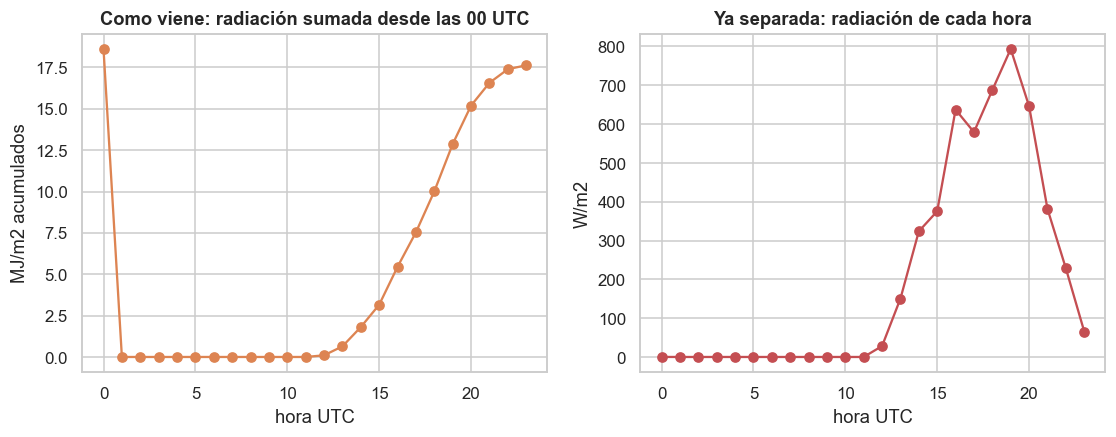

Pico de radiación de ese día: 794 W/m2


In [8]:
ssr_crudo = crudo["ssr"]
dia = ssr_crudo.loc["2020-01-02"]
dia_flujo = desacumular(ssr_crudo).loc["2020-01-02"] / 3600.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(24), dia.values / 1e6, marker="o", color="#dd8452")
axes[0].set_title("Como viene: radiación sumada desde las 00 UTC")
axes[0].set_xlabel("hora UTC"); axes[0].set_ylabel("MJ/m2 acumulados")
axes[1].plot(range(24), dia_flujo.values, marker="o", color="#c44e52")
axes[1].set_title("Ya separada: radiación de cada hora")
axes[1].set_xlabel("hora UTC"); axes[1].set_ylabel("W/m2")
plt.show()

print(f"Pico de radiación de ese día: {fmt(dia_flujo.max())} W/m2")

A la izquierda la curva solo crece: cada hora suma a la anterior y al llegar a la medianoche se reinicia de golpe. Esa forma escalonada no es radiación instantánea, es un contador. A la derecha, tras restar cada hora con la anterior, aparece la campana que se espera de un día: cero en la noche, subida desde el amanecer y un máximo cerca del mediodía solar que ese día llegó a unos 790 vatios por metro cuadrado. Si se promediara la curva de la izquierda sin separarla primero, el resultado mezclaría acumulados de distinta edad y no significaría nada. La lluvia se comporta igual, así que las dos se tratan de esta forma antes de cualquier cuenta.

## 4. Que los valores tengan sentido

Con todo cargado y convertido a sus unidades de siempre, miramos el rango de cada variable. La idea no es solo ver mínimos y máximos, sino confirmar que los números son los de un valle tropical a mil metros y no hay nada fuera de lugar.

In [9]:
df = pd.DataFrame(index=base)
df["t2m"] = crudo["t2m"] - 273.15
df["d2m"] = crudo["d2m"] - 273.15
df["stl1"] = crudo["stl1"] - 273.15
df["sp"] = crudo["sp"] / 100.0
df["u10"], df["v10"] = crudo["u10"], crudo["v10"]
df["blh"] = crudo["blh"].reindex(base)
df["u100"], df["v100"] = crudo["u100"].reindex(base), crudo["v100"].reindex(base)
df["ssr"] = (desacumular(crudo["ssr"]) / 3600.0).reindex(base)
df["tp"] = (desacumular(crudo["tp"]) * 1000.0).reindex(base)
df["rh"] = magnus_rh(df["t2m"], df["d2m"])
df["ws10"] = np.sqrt(df["u10"] ** 2 + df["v10"] ** 2)
df["wd10"] = (270 - np.degrees(np.arctan2(df["v10"], df["u10"]))) % 360
df["ws100"] = np.sqrt(df["u100"] ** 2 + df["v100"] ** 2)

etiquetas = {
    "t2m": "Temperatura a 2 m (C)", "d2m": "Punto de rocío (C)", "rh": "Humedad relativa (%)",
    "sp": "Presión superficie (hPa)", "blh": "Capa de mezcla (m)", "ws10": "Viento a 10 m (m/s)",
    "ssr": "Radiación (W/m2)", "tp": "Lluvia horaria (mm)",
}
resumen = df[list(etiquetas)].describe(percentiles=[0.05, 0.5, 0.95]).T
resumen = resumen[["min", "5%", "50%", "mean", "95%", "max"]]
resumen.index = [etiquetas[i] for i in resumen.index]
print(resumen.round(2).to_string())

                             min      5%     50%    mean     95%      max
Temperatura a 2 m (C)      13.19   16.99   19.48   19.96   23.96    27.61
Punto de rocío (C)         10.77   15.23   17.16   17.10   18.79    21.37
Humedad relativa (%)       47.85   68.78   86.40   84.08   93.30    98.77
Presión superficie (hPa)  862.12  866.43  869.75  869.74  873.00   875.91
Capa de mezcla (m)         11.10   35.73  152.57  279.83  806.85  1504.26
Viento a 10 m (m/s)         0.01    0.28    0.79    0.82    1.43     2.48
Radiación (W/m2)           -0.00    0.00    3.90  181.44  711.51  1013.57
Lluvia horaria (mm)        -0.00    0.02    0.27    0.49    1.73    12.21


Los números cuadran con el sitio. La temperatura se mueve entre unos 13 y 28 grados, con mediana cerca de 19 y medio, el rango templado de una ciudad tropical de altura. La presión ronda los 870 hectopascales y no los 1.013 del nivel del mar, justo lo que baja la presión a mil metros de altitud. La humedad relativa tiene mediana del 86 por ciento, aire húmedo casi todo el tiempo. La capa de mezcla va de unos pocos metros a poco más de 1.500, con mediana baja porque incluye todas las noches. El viento es la nota más marcada: la mediana ronda 0,8 metros por segundo y el máximo no llega a 2,5, vientos muy suaves de fondo de valle. Ningún valor se sale de lo físico, así que se puede confiar en las series para mirar sus ciclos.

## 5. El pulso del día

La variable que más le importa al proyecto es la altura de la capa de mezcla, porque es la que decide si los contaminantes se diluyen hacia arriba o se quedan atrapados cerca del suelo. Su ciclo diurno se ve promediando cada hora a lo largo de los cinco años. Lo miramos en hora local de Cali y marcamos el momento en que pasa el satélite.

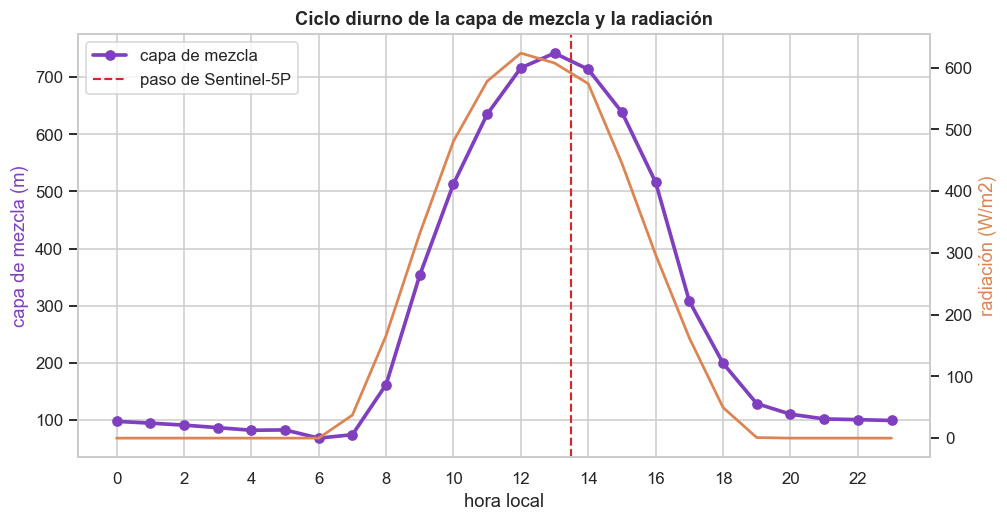

Capa de mezcla mínima: 68 m a las 6 h local
Capa de mezcla máxima: 742 m a las 13 h local


In [10]:
df["hora_local"] = (df.index + pd.Timedelta(hours=UTC_OFFSET)).hour
diurno = df.groupby("hora_local")[["blh", "t2m", "rh", "ssr"]].mean()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(diurno.index, diurno["blh"], color="#7f3fbf", lw=2.4, marker="o", label="capa de mezcla")
ax1.axvline(PASO_TROPOMI_LOCAL, color="#d62728", ls="--", lw=1.4, label="paso de Sentinel-5P")
ax1.set_xlabel("hora local"); ax1.set_ylabel("capa de mezcla (m)", color="#7f3fbf")
ax1.set_xticks(range(0, 24, 2))
ax2 = ax1.twinx()
ax2.plot(diurno.index, diurno["ssr"], color="#dd8452", lw=1.8, label="radiación")
ax2.set_ylabel("radiación (W/m2)", color="#dd8452")
ax2.grid(False)
ax1.set_title("Ciclo diurno de la capa de mezcla y la radiación")
ax1.legend(loc="upper left")
plt.show()

print(f"Capa de mezcla mínima: {fmt(diurno['blh'].min())} m a las {diurno['blh'].idxmin()} h local")
print(f"Capa de mezcla máxima: {fmt(diurno['blh'].max())} m a las {diurno['blh'].idxmax()} h local")

El ciclo es de manual y sigue al sol con un retraso. En la madrugada la capa de mezcla queda aplastada cerca de los 70 metros, porque sin sol no hay turbulencia que mezcle el aire. Apenas entra la radiación, sube rápido y alcanza su tope cerca de los 740 metros a la una de la tarde local, para desplomarse otra vez al caer el sol. El detalle que importa para el proyecto es que el satélite pasa justo en ese máximo: cuando Sentinel-5P toma la foto de la columna, la capa de mezcla está en su punto más alto del día, que es el momento de mayor dilución. Esa coincidencia es la que permite que ERA5 ayude a traducir la columna en concentración de superficie, porque entrega la altura sobre la que se reparte lo que el satélite ve.

## 6. El año en dos lluvias

Cali no tiene cuatro estaciones, tiene dos temporadas de lluvia y dos más secas, el patrón bimodal de los Andes. Sumamos la lluvia por día y la promediamos por mes para ver si ERA5 captura ese vaivén, y de paso miramos la temperatura mes a mes.

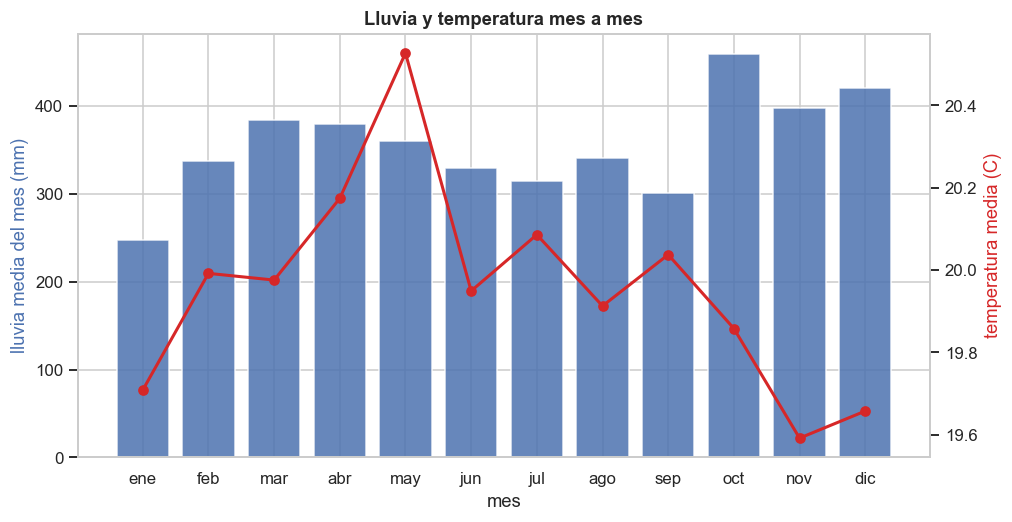

Lluvia anual que reporta ERA5: cerca de 4.337 mm


In [11]:
tp_diario = df["tp"].resample("1D").sum()
tp_mes = tp_diario.groupby(tp_diario.index.month).mean() * 30
t2m_mes = df["t2m"].groupby(df.index.month).mean()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, 13), tp_mes.values, color="#4c72b0", alpha=0.85, label="lluvia")
ax1.set_xticks(range(1, 13)); ax1.set_xticklabels(MESES)
ax1.set_ylabel("lluvia media del mes (mm)", color="#4c72b0")
ax1.set_xlabel("mes")
ax2 = ax1.twinx()
ax2.plot(range(1, 13), t2m_mes.values, color="#d62728", lw=2, marker="o", label="temperatura")
ax2.set_ylabel("temperatura media (C)", color="#d62728")
ax2.grid(False)
ax1.set_title("Lluvia y temperatura mes a mes")
plt.show()

print(f"Lluvia anual que reporta ERA5: cerca de {fmt(tp_diario.groupby(tp_diario.index.year).sum().mean())} mm")

El bimodal asoma, aunque desdibujado. Se ven más lluvias hacia marzo y mayo y un segundo tramo húmedo entre octubre y diciembre, con enero como el mes más seco, que es a grandes rasgos el calendario andino. La temperatura casi no se mueve en el año, cosa normal en el trópico, donde el día y la noche pesan más que las estaciones. Hay un punto que toca decir con franqueza: ERA5 reporta cerca de 4.300 milímetros de lluvia al año, varias veces lo que mide una estación dentro de la ciudad, que ronda los mil. Dos cosas lo explican. La celda gruesa promedia parte de la ladera occidental que da al Pacífico, una de las zonas más lluviosas del planeta, y además el modelo tiende a dejar caer lloviznas muy seguidas. La lectura para las fases siguientes es que la lluvia de ERA5 sirve para leer el ritmo estacional, no para tomarla como la lluvia exacta de Cali.

## 7. De dónde sopla el viento

El viento decide hacia dónde se van los contaminantes, así que importa su dirección, no solo su fuerza. Una rosa de los vientos reparte las horas según de dónde viene el aire y con qué velocidad, sobre los dieciséis rumbos de la brújula.

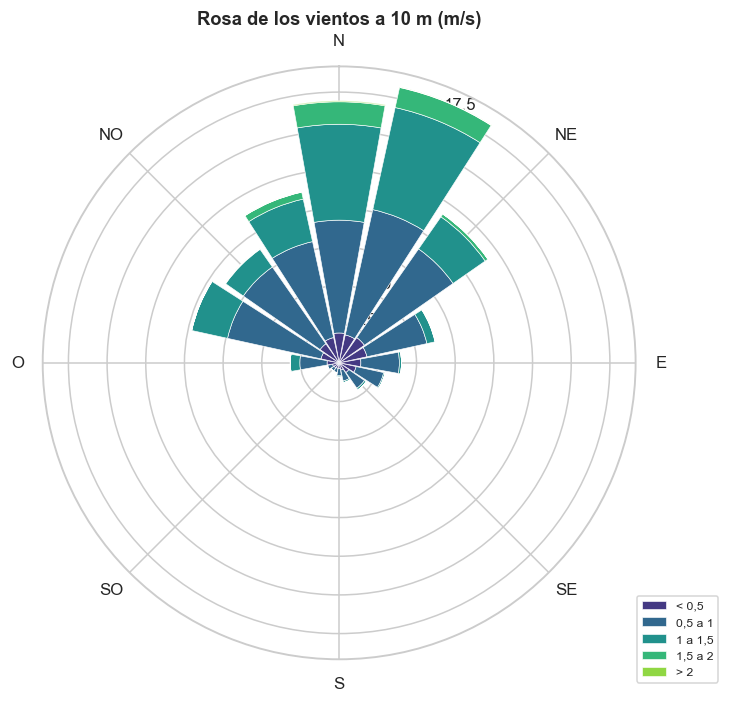

Viento medio a 10 m: 0,82 m/s   a 100 m: 1,49 m/s


In [12]:
sectores = 16
ancho = 360 / sectores
idx_sector = (((df["wd10"] + ancho / 2) // ancho) % sectores).astype(int)
bins_ws = [0, 0.5, 1.0, 1.5, 2.0, 99]
nombres_ws = ["< 0,5", "0,5 a 1", "1 a 1,5", "1,5 a 2", "> 2"]
cat_ws = pd.cut(df["ws10"], bins=bins_ws, labels=nombres_ws, right=False)
tabla = pd.crosstab(idx_sector, cat_ws, normalize=True) * 100

angulos = np.deg2rad(np.arange(sectores) * ancho)
colores = sns.color_palette("viridis", len(nombres_ws))
fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
fondo = np.zeros(sectores)
for et, c in zip(nombres_ws, colores):
    valores = tabla.get(et, pd.Series(0, index=range(sectores))).reindex(range(sectores)).fillna(0).values
    ax.bar(angulos, valores, width=np.deg2rad(ancho) * 0.9, bottom=fondo,
           color=c, edgecolor="white", lw=0.4, label=et)
    fondo += valores
ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SO", "O", "NO"])
ax.set_title("Rosa de los vientos a 10 m (m/s)")
ax.legend(loc="lower right", bbox_to_anchor=(1.15, -0.05), fontsize=8)
plt.show()

print(f"Viento medio a 10 m: {fmt(df['ws10'].mean(), 2)} m/s   a 100 m: {fmt(df['ws100'].mean(), 2)} m/s")

La rosa muestra un viento que viene sobre todo del norte y el nororiente, con un aporte del noroccidente, y casi nada del sur. Esa preferencia encaja con un valle largo orientado de norte a sur entre las dos cordilleras, que canaliza el aire por su eje. La fuerza es lo de menos: casi todas las barras caen por debajo de un metro y medio por segundo, vientos flojos que mueven los contaminantes despacio. A cien metros el viento es algo más fuerte, cerca de metro y medio de media, porque arriba pesa menos el rozamiento del suelo. Un viento tan suave ayuda a que lo que se emite en el norte industrial alcance a llegar al sur de la ciudad.

## 8. Cómo se acompañan las variables

Las variables meteorológicas no son independientes, y para el modelo importa saber cuáles se mueven juntas. Calculamos la correlación de rangos de Spearman sobre los valores diarios, que captura relaciones aunque no sean rectas, y nos fijamos en con qué se relaciona la capa de mezcla.

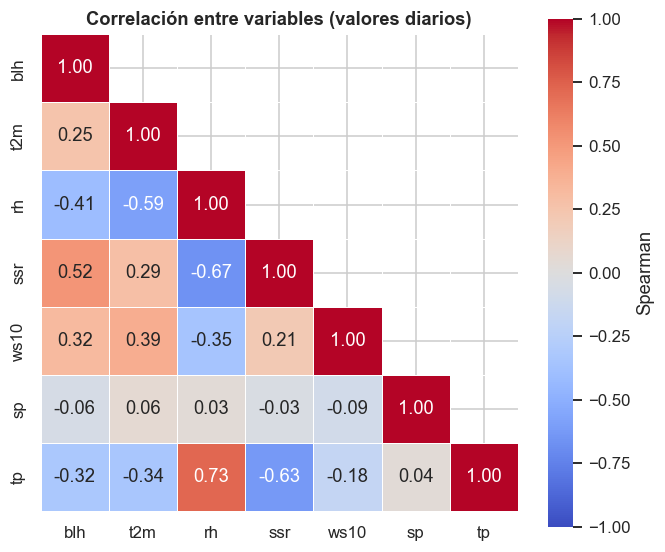

Correlación de la capa de mezcla con el resto:
ssr     0.520
ws10    0.315
t2m     0.253
sp     -0.060
tp     -0.325
rh     -0.408


In [13]:
diario = df[["blh", "t2m", "rh", "ssr", "ws10", "sp"]].resample("1D").mean()
diario["tp"] = tp_diario
corr = diario.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"label": "Spearman"}, ax=ax)
ax.set_title("Correlación entre variables (valores diarios)")
plt.show()

print("Correlación de la capa de mezcla con el resto:")
print(corr["blh"].drop("blh").round(3).sort_values(ascending=False).to_string())

Las relaciones tienen el signo que la física pide, y eso da confianza en el dato. La capa de mezcla sube con la radiación, que es la correlación más fuerte y positiva cerca de 0,52, porque el sol es el motor que mezcla el aire. Sube también con el viento y con la temperatura, las otras dos fuentes de turbulencia. Y baja con la humedad y con la lluvia, los días nublados en que la capa se queda comprimida. Para el proyecto esto respalda usar la capa de mezcla como una de las variables que explican la concentración de superficie: se comporta de forma coherente con el resto del clima y resume bien si el día fue de dispersión o de estancamiento.

## 9. El año del Niño y el de la Niña

Cinco años dan para ver algo más lento que el ciclo estacional. El periodo 2020 a 2024 arrancó con una racha de tres años de La Niña y terminó virando hacia El Niño, y esos dos estados dejan huella en el clima local. Promediamos por año para buscar esa señal.

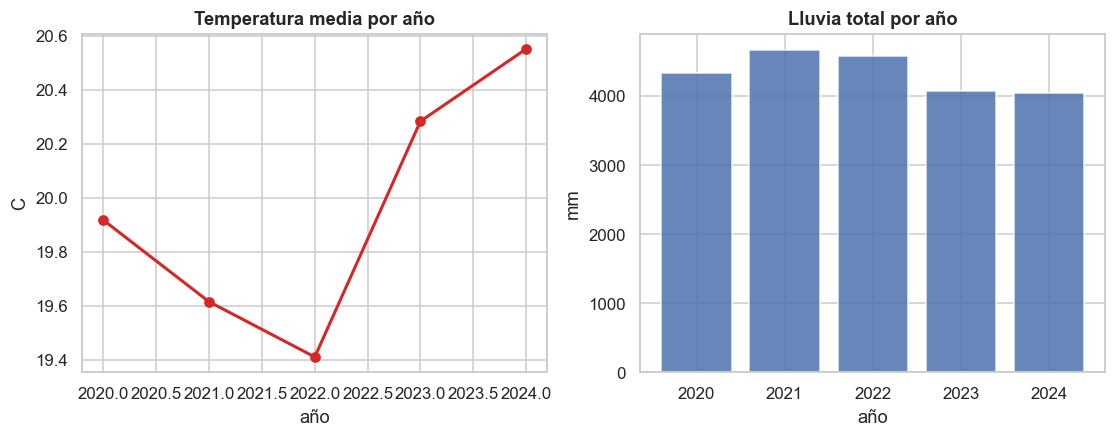

       t2m    blh  lluvia
anio                     
2020  19.9  285.9  4328.9
2021  19.6  278.7  4666.4
2022  19.4  273.1  4582.2
2023  20.3  275.3  4073.5
2024  20.6  286.2  4033.4


In [14]:
anual = df[["t2m", "blh"]].groupby(df.index.year).mean()
anual.index.name = "anio"
anual["lluvia"] = tp_diario.groupby(tp_diario.index.year).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(anual.index, anual["t2m"], marker="o", color="#d62728", lw=2)
axes[0].set_title("Temperatura media por año"); axes[0].set_ylabel("C"); axes[0].set_xlabel("año")
axes[1].bar(anual.index.astype(str), anual["lluvia"], color="#4c72b0", alpha=0.85)
axes[1].set_title("Lluvia total por año"); axes[1].set_ylabel("mm"); axes[1].set_xlabel("año")
plt.show()

print(anual.round(1).to_string())

La señal aparece. Los años de La Niña, de 2020 a 2022, salieron más frescos, con la temperatura media cerca de 19 grados, y más lluviosos, mientras que 2023 y 2024, ya con El Niño asomando, fueron los más cálidos, por encima de 20 grados, y los más secos del lustro. Es la respuesta de libro: La Niña enfría y moja el occidente colombiano, El Niño calienta y seca. Para el proyecto esto es un aviso de que los cinco años no son intercambiables; un modelo que mezcle 2021 con 2024 está juntando dos regímenes de clima distintos, y conviene tenerlo en cuenta al armar y al validar.

## Lo que nos llevamos

ERA5 entra al panel como el telón de fondo meteorológico, y este recorrido confirma que sirve para eso aunque tenga sus límites. Las once variables llegan completas, sin huecos en los cinco años, y con valores físicos sanos para un valle tropical de altura: temperatura templada, presión baja por los mil metros, aire húmedo y vientos muy suaves canalizados de norte a sur. La capa de mezcla, que es la pieza clave, muestra un ciclo diurno limpio con su máximo cerca de las dos de la tarde, justo cuando pasa el satélite, lo que la vuelve la mejor candidata para traducir la columna de gases en concentración de superficie. Sus correlaciones con la radiación, el viento y la humedad apuntan todas en la dirección correcta.

Quedan tres cosas anotadas para las fases siguientes. La resolución es gruesa, doce celdas en el mejor de los casos, así que ERA5 aporta contexto regional y no detalle de barrio, y habrá que llevarlo a la grilla fina del resto del panel por interpolación. La lluvia viene sobreestimada por la celda que toca la ladera del Pacífico y por la llovizna del modelo, de modo que sirve para el ritmo estacional pero no como medida exacta. Y los cinco años cargan el contraste entre La Niña y El Niño, una fuente de variación lenta que conviene respetar cuando se separen los datos para entrenar y para validar.